In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Data preprocessing

Training image processing

In [2]:
training_set=tf.keras.utils.image_dataset_from_directory(
    'Train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 18345 files belonging to 10 classes.


Validation image processing

In [3]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 4585 files belonging to 10 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[110.25  98.25 102.25]
   [115.5  103.5  107.5 ]
   [113.25 101.25 105.25]
   ...
   [154.25 143.25 149.25]
   [147.25 136.25 142.25]
   [154.5  143.5  149.5 ]]

  [[113.75 101.75 105.75]
   [117.5  105.5  109.5 ]
   [127.25 115.25 119.25]
   ...
   [144.25 133.25 139.25]
   [151.25 140.25 146.25]
   [139.5  128.5  134.5 ]]

  [[ 97.5   85.5   89.5 ]
   [112.25 100.25 104.25]
   [112.5  100.5  104.5 ]
   ...
   [138.75 127.75 133.75]
   [138.75 127.75 133.75]
   [149.   138.   144.  ]]

  ...

  [[106.5   96.5  107.5 ]
   [109.25  99.25 110.25]
   [120.75 110.75 121.75]
   ...
   [120.5  112.5  125.5 ]
   [127.75 119.75 132.75]
   [120.75 112.75 125.75]]

  [[118.   108.   119.  ]
   [105.    95.   106.  ]
   [141.25 131.25 142.25]
   ...
   [121.75 113.75 126.75]
   [138.25 130.25 143.25]
   [135.75 127.75 140.75]]

  [[130.   120.   131.  ]
   [120.25 110.25 121.25]
   [115.75 105.75 116.75]
   ...
   [133.   125.   138.  ]
   [161.   153.   166.  ]
   [138.   130.   14

Building model

In [6]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [7]:
model=Sequential()

Building convolution layer

In [8]:
model.add(Conv2D(filters=10,kernel_size=3,padding='same',activation='relu',input_shape=(128,128,3)))
model.add(Conv2D(filters=10,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

C:\Users\geeth\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=(128,128,3)))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=(128,128,3)))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',input_shape=(128,128,3)))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu',input_shape=(128,128,3)))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [13]:
model.add(Dropout(0.25))

In [14]:
model.add(Flatten())

In [15]:
model.add(Dense(units=1024, activation='relu'))

In [16]:
model.add(Dense(units=10,activation='softmax'))

Compiling model

In [17]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,799,024 (25.94 MB)

 Trainable params: 6,799,024 (25.94 MB)

 Non-trainable params: 0 (0.00 B)

Model Training

In [19]:
training_history=model.fit(x=training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 568s 978ms/step - accuracy: 0.3889 - loss: 1.7631 - val_accuracy: 0.7575 - val_loss: 0.6647
Epoch 2/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 436s 758ms/step - accuracy: 0.7672 - loss: 0.6495 - val_accuracy: 0.8513 - val_loss: 0.4300
Epoch 3/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 425s 740ms/step - accuracy: 0.8667 - loss: 0.3780 - val_accuracy: 0.8611 - val_loss: 0.3928
Epoch 4/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 389s 677ms/step - accuracy: 0.8892 - loss: 0.3237 - val_accuracy: 0.8868 - val_loss: 0.3201
Epoch 5/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 410s 714ms/step - accuracy: 0.9124 - loss: 0.2419 - val_accuracy: 0.9186 - val_loss: 0.2382
Epoch 6/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 396s 690ms/step - accuracy: 0.9375 - loss: 0.1748 - val_accuracy: 0.9034 - val_loss: 0.3243
Epoch 7/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 446s 696ms/step - accuracy: 0.9547 - loss: 0.1295 - val_accuracy: 0.9315 - val_loss: 0.2079
Epoch 8/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 396s 690ms/step - accuracy: 0.9639 -

Model evaluation

In [20]:
train_loss,train_accu=model.evaluate(training_set)

574/574 ━━━━━━━━━━━━━━━━━━━━ 116s 203ms/step - accuracy: 0.9608 - loss: 0.1089


In [21]:
print(train_loss,train_accu)

0.09928452968597412 0.9648405313491821


In [22]:
val_loss,val_accu=model.evaluate(validation_set)

144/144 ━━━━━━━━━━━━━━━━━━━━ 30s 208ms/step - accuracy: 0.9078 - loss: 0.3137


In [23]:
print(val_loss,val_accu)

0.30493488907814026 0.9101417660713196


Saving model

In [24]:
model.save("trained_model.keras")

In [25]:
training_history.history

{'accuracy': [0.5500681400299072,
  0.7971654534339905,
  0.8735350370407104,
  0.9007359147071838,
  0.924557089805603,
  0.9419460296630859,
  0.9548650979995728,
  0.9647860527038574,
  0.9677841663360596,
  0.9712728261947632],
 'loss': [1.279892921447754,
  0.5723062753677368,
  0.3569512963294983,
  0.2914957106113434,
  0.20831145346164703,
  0.16421203315258026,
  0.12763945758342743,
  0.1040225550532341,
  0.0973215103149414,
  0.08098442852497101],
 'val_accuracy': [0.7574700117111206,
  0.8512541055679321,
  0.8610687255859375,
  0.8868048191070557,
  0.9186477661132812,
  0.9033805727958679,
  0.9315158128738403,
  0.941766619682312,
  0.9339149594306946,
  0.9101417660713196],
 'val_loss': [0.6647137403488159,
  0.430026650428772,
  0.3927597403526306,
  0.3201262056827545,
  0.23818686604499817,
  0.3243459463119507,
  0.20788992941379547,
  0.16828547418117523,
  0.1988261342048645,
  0.3049350082874298]}

In [26]:
import matplotlib.pyplot as plt
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

Accuracy visualization

<function matplotlib.pyplot.show(close=None, block=None)>

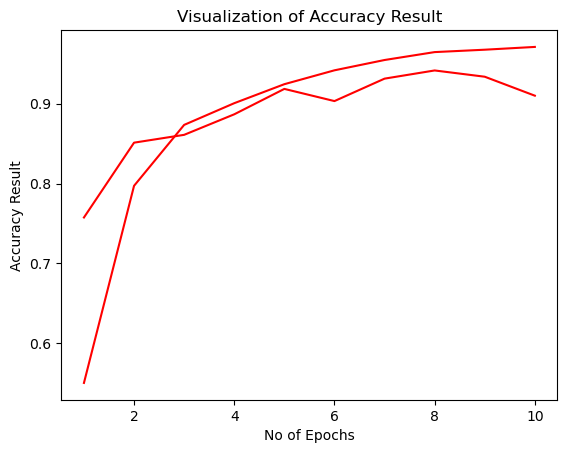

In [27]:
import matplotlib.pyplot as plt
epochs=[i for i in range(1,11)]
epochs
plt.plot(epochs,training_history.history['accuracy'],color='red',label="Training Accuracy")
plt.plot(epochs,training_history.history['val_accuracy'],color='red',label="Validation Accuracy")
plt.xlabel("No of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.show

Some other metrics for model visualization

In [28]:
class_name = validation_set.class_names
class_name

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [29]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 4585 files belonging to 10 classes.


In [30]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

4585/4585 ━━━━━━━━━━━━━━━━━━━━ 101s 22ms/step


(array([[9.99636054e-01, 3.37047066e-04, 4.62505159e-06, ...,
         1.71846586e-05, 1.44545888e-13, 1.32436159e-10],
        [1.00000000e+00, 6.15721085e-10, 6.22020879e-10, ...,
         8.20298829e-10, 2.18046815e-18, 9.99046774e-16],
        [1.00000000e+00, 4.81952978e-10, 2.19339282e-12, ...,
         1.39454184e-10, 2.50782778e-18, 3.49419323e-15],
        ...,
        [1.14615817e-04, 3.32422587e-06, 3.92953772e-03, ...,
         1.40904785e-05, 1.48867994e-05, 9.95689452e-01],
        [3.01506021e-04, 1.28189072e-06, 4.57642309e-05, ...,
         4.67215023e-06, 1.54591442e-06, 9.99579847e-01],
        [5.41850852e-07, 6.13741690e-07, 2.34822583e-05, ...,
         4.22462954e-09, 4.79849760e-08, 9.97851849e-01]], dtype=float32),
 (4585, 10))

In [31]:
predicted_categories=tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(4585,), dtype=int64, numpy=array([0, 0, 0, ..., 9, 9, 9], dtype=int64)>

In [32]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(4585, 10), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [33]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(4585,), dtype=int64, numpy=array([0, 0, 0, ..., 9, 9, 9], dtype=int64)>

In [34]:
predicted_categories

<tf.Tensor: shape=(4585,), dtype=int64, numpy=array([0, 0, 0, ..., 9, 9, 9], dtype=int64)>

In [35]:
!pip install scikit-learn

In [36]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
cm = confusion_matrix(Y_true,predicted_categories)
precision = precision_score(Y_true, predicted_categories, average='weighted', zero_division=1)
recall = recall_score(Y_true, predicted_categories, average='weighted', zero_division=1)
f1 = f1_score(Y_true, predicted_categories, average='weighted', zero_division=1)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.9206704091018685
Recall: 0.9101417666303162
F1-score: 0.9118335534551406


In [37]:
print(classification_report(Y_true, predicted_categories, zero_division=1,target_names=class_name))

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.94      0.95      0.94       425
                        Tomato___Early_blight       0.71      0.95      0.81       480
                         Tomato___Late_blight       0.91      0.83      0.87       463
                           Tomato___Leaf_Mold       0.98      0.89      0.94       470
                  Tomato___Septoria_leaf_spot       0.92      0.84      0.88       436
Tomato___Spider_mites Two-spotted_spider_mite       0.83      0.97      0.89       435
                         Tomato___Target_Spot       0.94      0.80      0.86       457
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.99      0.95      0.97       490
                 Tomato___Tomato_mosaic_virus       1.00      0.96      0.98       448
                             Tomato___healthy       0.99      0.97      0.98       481

                                     accu

In [38]:
cm=confusion_matrix(Y_true,predicted_categories)
cm

array([[402,  19,   2,   0,   0,   0,   2,   0,   0,   0],
       [  4, 454,  11,   1,   1,   3,   3,   3,   0,   0],
       [  9,  58, 386,   0,   7,   1,   1,   0,   0,   1],
       [  0,  12,  16, 420,  13,   7,   0,   2,   0,   0],
       [  9,  45,   2,   4, 367,   4,   5,   0,   0,   0],
       [  0,   8,   0,   1,   0, 422,   3,   1,   0,   0],
       [  0,  35,   2,   0,   4,  45, 365,   0,   1,   5],
       [  2,   4,   1,   0,   0,  19,   0, 464,   0,   0],
       [  1,   4,   0,   1,   3,   9,   2,   0, 428,   0],
       [  0,   1,   3,   0,   5,   1,   6,   0,   0, 465]], dtype=int64)

Confusion matrix visualization

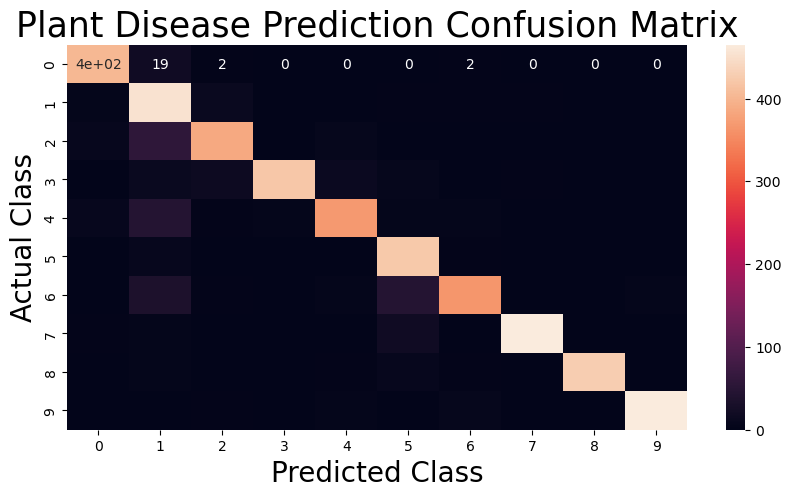

In [45]:
plt.figure(figsize=(10,5))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()